# Pipeline 3 — Vision Transformer (ViT-B/16)

Training is performed in two stages:

1. Stage 1 — Frozen ViT backbone, train classification head for 10 epochs
2. Stage 2 — Unfreeze the final two transformer encoder blocks and classification head for 5 additional epochs

In [ ]:
import os
import random
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import datasets, transforms, models

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from google.colab import files

In [ ]:
# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("Torchvision version:", __import__("torchvision").__version__)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
Torchvision version: 0.26.0+cu128
Device: cuda
GPU: Tesla T4


In [ ]:
!pip -q install kagglehub
import kagglehub

# Download the latest version of the dataset
dataset_path = kagglehub.dataset_download(
    "ajg117/indian-paintings-dataset"
)

print("Dataset path:")
print(dataset_path)

Using Colab cache for faster access to the 'indian-paintings-dataset' dataset.
Dataset path:
/kaggle/input/indian-paintings-dataset


In [ ]:
# Load dataset without transforms.
# Transforms will be applied later through TransformSubset.
base_dataset = datasets.ImageFolder(
    root=dataset_path,
    transform=None
)

class_names = base_dataset.classes
NUM_CLASSES = len(class_names)

print("Number of images:", len(base_dataset))
print("Number of classes:", NUM_CLASSES)
print("\nClasses:")
for idx, class_name in enumerate(class_names):
    print(f"{idx}: {class_name}")

Number of images: 953
Number of classes: 8

Classes:
0: gond painting
1: kalighat painting
2: kangra painting
3: kerala mural
4: madhubani painting
5: mandana art drawing
6: pichwai painting
7: warli painting


In [ ]:
print("Class-to-index mapping:")
print(base_dataset.class_to_idx)

print("\nFirst sample:")
image, label = base_dataset[0]

print("Image type:", type(image))
print("Image size:", image.size)
print("Label:", label)
print("Class:", class_names[label])

Class-to-index mapping:
{'gond painting': 0, 'kalighat painting': 1, 'kangra painting': 2, 'kerala mural': 3, 'madhubani painting': 4, 'mandana art drawing': 5, 'pichwai painting': 6, 'warli painting': 7}

First sample:
Image type: <class 'PIL.Image.Image'>
Image size: (471, 625)
Label: 0
Class: gond painting


In [ ]:
IMAGE_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Training transform:")
print(train_transform)

print("\nValidation/Test transform:")
print(test_transform)

Training transform:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=None)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Validation/Test transform:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [ ]:
total_size = len(base_dataset)

train_size = int(0.70 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

generator = torch.Generator().manual_seed(SEED)

train_subset, val_subset, test_subset = random_split(
    base_dataset,
    [train_size, val_size, test_size],
    generator=generator
)

print("Dataset split:")
print(f"Total:      {total_size}")
print(f"Training:   {len(train_subset)} ({len(train_subset)/total_size:.2%})")
print(f"Validation: {len(val_subset)} ({len(val_subset)/total_size:.2%})")
print(f"Testing:    {len(test_subset)} ({len(test_subset)/total_size:.2%})")

Dataset split:
Total:      953
Training:   667 (69.99%)
Validation: 142 (14.90%)
Testing:    144 (15.11%)


In [ ]:
class TransformSubset(Dataset):
    """
    Applies a transform to samples from an existing Subset.

    The original ImageFolder dataset remains transform-free so that
    different transformations can be applied to the training and
    validation/test partitions without changing the underlying split.
    """

    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, index):
        image, label = self.subset[index]

        if self.transform is not None:
            image = self.transform(image)

        return image, label

**Split dataset**

In [ ]:
train_dataset = TransformSubset(
    train_subset,
    train_transform
)

val_dataset = TransformSubset(
    val_subset,
    test_transform
)

test_dataset = TransformSubset(
    test_subset,
    test_transform
)

print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))

Train dataset: 667
Validation dataset: 142
Test dataset: 144


**DataLoaders**

In [ ]:
BATCH_SIZE = 32

pin_memory = torch.cuda.is_available()

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=pin_memory
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=pin_memory
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=pin_memory
)

print("Batch size:", BATCH_SIZE)
print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Batch size: 32
Training batches: 21
Validation batches: 5
Test batches: 5


In [ ]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

print("Image dtype:", images.dtype)
print("Label dtype:", labels.dtype)

print("Labels in first batch:")
print(labels.tolist())

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Image dtype: torch.float32
Label dtype: torch.int64
Labels in first batch:
[4, 7, 7, 2, 6, 5, 0, 3, 1, 7, 4, 2, 6, 1, 1, 2, 1, 1, 1, 1, 1, 2, 2, 3, 3, 1, 7, 7, 7, 1, 5, 0]


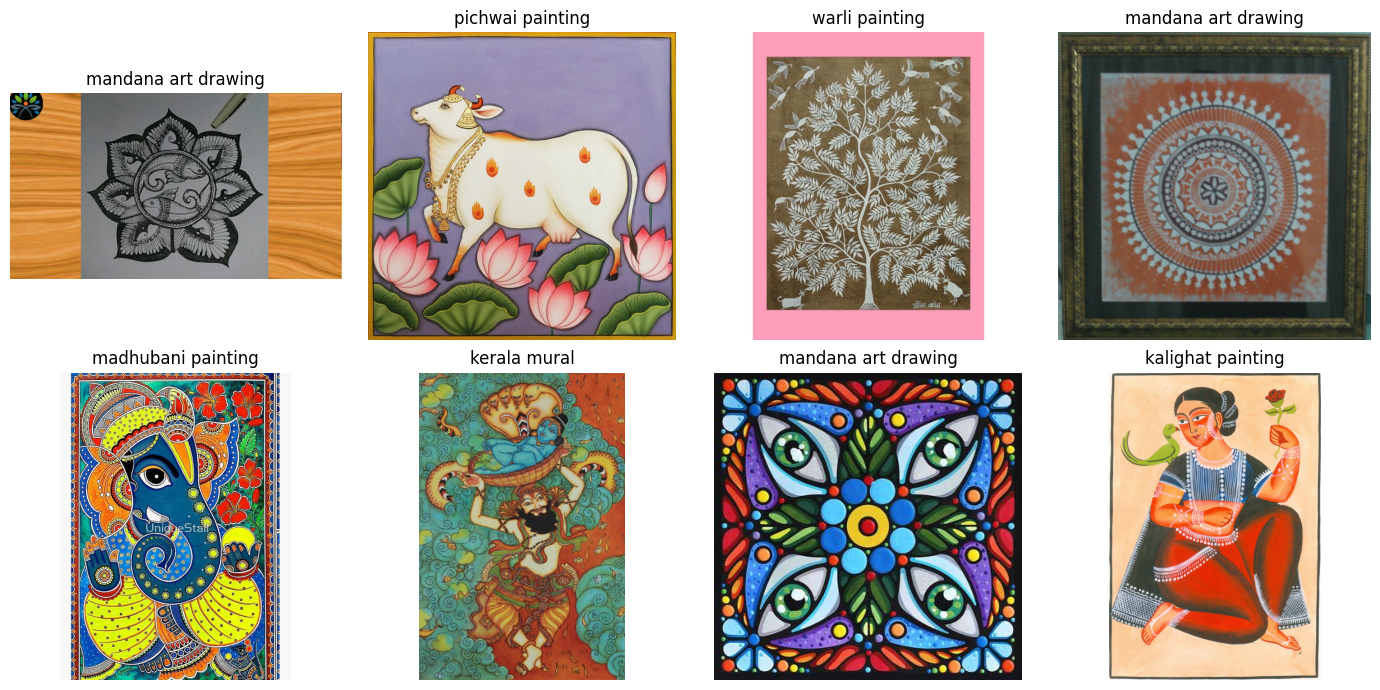

In [ ]:
# Visualize sample images from the original dataset
# without using DataLoader, because the samples are PIL Images.

num_samples = 8

# Select random indices from the training subset
sample_indices = torch.randperm(len(train_subset))[:num_samples]

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for ax, subset_index in zip(axes.flat, sample_indices):

    # train_subset contains PIL images because base_dataset has transform=None
    image, label = train_subset[subset_index.item()]

    ax.imshow(image)
    ax.set_title(class_names[label])
    ax.axis("off")

plt.tight_layout()
plt.show()

**Load ImageNet-Pretrained ViT-B/16**

In [ ]:
weights = models.ViT_B_16_Weights.DEFAULT

model = models.vit_b_16(
    weights=weights
)

print("Pretrained ViT-B/16 loaded successfully.")
print("Original classifier:")
print(model.heads)

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:03<00:00, 89.5MB/s]


Pretrained ViT-B/16 loaded successfully.
Original classifier:
Sequential(
  (head): Linear(in_features=768, out_features=1000, bias=True)
)


In [ ]:
print(model)

print("ViT Encoder:")
print(model.encoder)

print("Number of encoder blocks:", len(model.encoder.layers))

print("\nEncoder block names:")
for idx, layer in enumerate(model.encoder.layers):
    print(idx, "->", layer.__class__.__name__)

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

**Replace Classification Head**

In [ ]:
num_features = model.heads.head.in_features

print("Original classifier input features:", num_features)

model.heads.head = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(num_features, NUM_CLASSES)
)

print("\nNew classification head:")
print(model.heads)

Original classifier input features: 768

New classification head:
Sequential(
  (head): Sequential(
    (0): Dropout(p=0.4, inplace=False)
    (1): Linear(in_features=768, out_features=8, bias=True)
  )
)


In [ ]:
model = model.to(device)

print("Model device:", next(model.parameters()).device)

Model device: cuda:0


#Stage 1 — Frozen ViT

In [ ]:
# Freeze every parameter first
for param in model.parameters():
    param.requires_grad = False

# Re-enable only the classification head
for param in model.heads.parameters():
    param.requires_grad = True

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

total_params = sum(
    p.numel()
    for p in model.parameters()
)

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters:    {total_params - trainable_params:,}")

Total parameters:     85,804,808
Trainable parameters: 6,152
Frozen parameters:    85,798,656


##Verify Freezing

In [ ]:
print("Trainable parameters during Stage 1:\n")

for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)

Trainable parameters during Stage 1:

heads.head.1.weight
heads.head.1.bias


##Loss, Optimizer and Scheduler

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.heads.parameters(),
    lr=0.001
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

print("Criterion:", criterion)
print("Optimizer:", optimizer.__class__.__name__)
print("Initial learning rate:", optimizer.param_groups[0]["lr"])
print("Scheduler:", scheduler.__class__.__name__)

Criterion: CrossEntropyLoss()
Optimizer: Adam
Initial learning rate: 0.001
Scheduler: ReduceLROnPlateau


##Training Functions

###Training Function

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

###Validation Function

In [ ]:
def validate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

##Stage 1 Training

In [ ]:
# Training Configurations
STAGE1_EPOCHS = 10

best_val_accuracy = -float("inf")
best_epoch = None

best_model_path = "/content/vit_b16_best.pth"

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

epoch_stages = []

print("Stage 1 epochs:", STAGE1_EPOCHS)
print("Best checkpoint:", best_model_path)

Stage 1 epochs: 10
Best checkpoint: /content/vit_b16_best.pth


In [ ]:
# Training Loop
print("=" * 70)
print("STAGE 1 — FROZEN ViT BACKBONE")
print("=" * 70)

for epoch in range(STAGE1_EPOCHS):

    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_accuracy = validate(
        model,
        val_loader,
        criterion,
        device
    )

    # Scheduler must use validation accuracy
    scheduler.step(val_accuracy)

    current_lr = optimizer.param_groups[0]["lr"]

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)
    epoch_stages.append("Stage 1")

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy
        best_epoch = epoch + 1

        torch.save(
            model.state_dict(),
            best_model_path
        )

        checkpoint_status = " <-- BEST CHECKPOINT"
    else:
        checkpoint_status = ""

    print(
        f"Epoch [{epoch + 1:02d}/{STAGE1_EPOCHS}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f} | "
        f"LR: {current_lr:.6f}"
        f"{checkpoint_status}"
    )

print("\nStage 1 complete.")
print(f"Best validation accuracy so far: {best_val_accuracy:.4f}")

STAGE 1 — FROZEN ViT BACKBONE


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [01/10] Train Loss: 1.6965 | Train Acc: 0.3808 | Val Loss: 1.3181 | Val Acc: 0.5704 | LR: 0.001000 <-- BEST CHECKPOINT


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [02/10] Train Loss: 1.0707 | Train Acc: 0.6792 | Val Loss: 0.9497 | Val Acc: 0.7394 | LR: 0.001000 <-- BEST CHECKPOINT


...

Epoch [08/10] Train Loss: 0.4505 | Train Acc: 0.8651 | Val Loss: 0.6174 | Val Acc: 0.8169 | LR: 0.001000 <-- BEST CHECKPOINT


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [09/10] Train Loss: 0.4011 | Train Acc: 0.9010 | Val Loss: 0.6000 | Val Acc: 0.8310 | LR: 0.001000 <-- BEST CHECKPOINT


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [10/10] Train Loss: 0.3989 | Train Acc: 0.8981 | Val Loss: 0.5976 | Val Acc: 0.8169 | LR: 0.001000

Stage 1 complete.
Best validation accuracy so far: 0.8310


#Stage-2 : Selective fine-tuning

**Inspect Final Encoder Blocks**

In [ ]:
print("Available ViT encoder blocks:")

for idx, layer in enumerate(model.encoder.layers):
    print(f"Block {idx}: {layer.__class__.__name__}")

print("\nFinal two blocks:")
print(model.encoder.layers[-2:])

Available ViT encoder blocks:
Block 0: EncoderBlock
Block 1: EncoderBlock
Block 2: EncoderBlock
Block 3: EncoderBlock
Block 4: EncoderBlock
Block 5: EncoderBlock
Block 6: EncoderBlock
Block 7: EncoderBlock
Block 8: EncoderBlock
Block 9: EncoderBlock
Block 10: EncoderBlock
Block 11: EncoderBlock

Final two blocks:
Sequential(
  (encoder_layer_10): EncoderBlock(
    (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
    (self_attention): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
    )
    (dropout): Dropout(p=0.0, inplace=False)
    (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
    (mlp): MLPBlock(
      (0): Linear(in_features=768, out_features=3072, bias=True)
      (1): GELU(approximate='none')
      (2): Dropout(p=0.0, inplace=False)
      (3): Linear(in_features=3072, out_features=768, bias=True)
      (4): Dropout(p=0.0, inplace=False)
    )
  )
  (encoder_layer_11): EncoderBlock(
 

**Unfreeze Final Two Transformer Blocks**

In [ ]:
# Keep the entire model frozen first
for param in model.parameters():
    param.requires_grad = False

# Train the classification head
for param in model.heads.parameters():
    param.requires_grad = True

# Fine-tune only the final two transformer encoder blocks
for param in model.encoder.layers[-2:].parameters():
    param.requires_grad = True

print("Trainable modules:")
print("- Final two transformer encoder blocks")
print("- Classification head")

Trainable modules:
- Final two transformer encoder blocks
- Classification head


**Verify Stage 2 Trainable Parameters**

In [ ]:
print("Trainable parameter groups during Stage 2:\n")

for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)

Trainable parameter groups during Stage 2:

encoder.layers.encoder_layer_10.ln_1.weight
encoder.layers.encoder_layer_10.ln_1.bias
encoder.layers.encoder_layer_10.self_attention.in_proj_weight
encoder.layers.encoder_layer_10.self_attention.in_proj_bias
encoder.layers.encoder_layer_10.self_attention.out_proj.weight
encoder.layers.encoder_layer_10.self_attention.out_proj.bias
encoder.layers.encoder_layer_10.ln_2.weight
encoder.layers.encoder_layer_10.ln_2.bias
encoder.layers.encoder_layer_10.mlp.0.weight
encoder.layers.encoder_layer_10.mlp.0.bias
encoder.layers.encoder_layer_10.mlp.3.weight
encoder.layers.encoder_layer_10.mlp.3.bias
encoder.layers.encoder_layer_11.ln_1.weight
encoder.layers.encoder_layer_11.ln_1.bias
encoder.layers.encoder_layer_11.self_attention.in_proj_weight
encoder.layers.encoder_layer_11.self_attention.in_proj_bias
encoder.layers.encoder_layer_11.self_attention.out_proj.weight
encoder.layers.encoder_layer_11.self_attention.out_proj.bias
encoder.layers.encoder_layer_1

In [ ]:
stage2_trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

stage2_frozen_params = sum(
    p.numel()
    for p in model.parameters()
    if not p.requires_grad
)

print(f"Stage 2 trainable parameters: {stage2_trainable_params:,}")
print(f"Stage 2 frozen parameters:    {stage2_frozen_params:,}")

Stage 2 trainable parameters: 14,181,896
Stage 2 frozen parameters:    71,622,912


**Stage 2 Optimizer and Scheduler**

In [ ]:
FINE_TUNE_LR = 1e-4

optimizer = optim.Adam(
    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),
    lr=FINE_TUNE_LR
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

print("Fine-tuning learning rate:", FINE_TUNE_LR)
print("Optimizer:", optimizer.__class__.__name__)
print("Scheduler:", scheduler.__class__.__name__)

Fine-tuning learning rate: 0.0001
Optimizer: Adam
Scheduler: ReduceLROnPlateau


##Stage 2 Training

##Loop

In [ ]:
STAGE2_EPOCHS = 5

stage1_epochs_completed = STAGE1_EPOCHS

print("=" * 70)
print("STAGE 2 — SELECTIVE ViT FINE-TUNING")
print("=" * 70)

for epoch in range(STAGE2_EPOCHS):

    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_accuracy = validate(
        model,
        val_loader,
        criterion,
        device
    )

    scheduler.step(val_accuracy)

    current_lr = optimizer.param_groups[0]["lr"]

    global_epoch = stage1_epochs_completed + epoch + 1

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)
    epoch_stages.append("Stage 2")

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy
        best_epoch = global_epoch

        torch.save(
            model.state_dict(),
            best_model_path
        )

        checkpoint_status = " <-- BEST CHECKPOINT"
    else:
        checkpoint_status = ""

    print(
        f"Epoch [{global_epoch:02d}/15] "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f} | "
        f"LR: {current_lr:.6f}"
        f"{checkpoint_status}"
    )

print("\nStage 2 complete.")
print(f"Best validation accuracy: {best_val_accuracy:.4f}")
print(f"Best epoch: {best_epoch}")

STAGE 2 — SELECTIVE ViT FINE-TUNING


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [11/15] Train Loss: 0.3522 | Train Acc: 0.9010 | Val Loss: 0.4935 | Val Acc: 0.8592 | LR: 0.000100 <-- BEST CHECKPOINT


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [12/15] Train Loss: 0.1722 | Train Acc: 0.9685 | Val Loss: 0.4749 | Val Acc: 0.8521 | LR: 0.000100


...

Epoch [13/15] Train Loss: 0.0942 | Train Acc: 0.9835 | Val Loss: 0.4382 | Val Acc: 0.8521 | LR: 0.000100


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [14/15] Train Loss: 0.0577 | Train Acc: 0.9895 | Val Loss: 0.4565 | Val Acc: 0.8451 | LR: 0.000050


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [15/15] Train Loss: 0.0352 | Train Acc: 0.9970 | Val Loss: 0.4866 | Val Acc: 0.8662 | LR: 0.000050 <-- BEST CHECKPOINT

Stage 2 complete.
Best validation accuracy: 0.8662
Best epoch: 15


#Training Curves

##DataFrame



In [ ]:
history = pd.DataFrame({
    "epoch": range(1, len(train_losses) + 1),
    "stage": epoch_stages,
    "train_loss": train_losses,
    "train_accuracy": train_accuracies,
    "val_loss": val_losses,
    "val_accuracy": val_accuracies
})

history

,epoch,stage,train_loss,train_accuracy,val_loss,val_accuracy
0,1,Stage 1,1.696515,0.380810,1.318089,0.570423
1,2,Stage 1,1.070670,0.679160,0.949738,0.739437
2,3,Stage 1,0.816479,0.763118,0.806291,0.767606
3,4,Stage 1,0.671169,0.808096,0.736337,0.781690
4,5,Stage 1,0.599977,0.826087,0.690165,0.781690
5,6,Stage 1,0.517855,0.851574,0.658166,0.809859
6,7,Stage 1,0.466729,0.880060,0.639955,0.809859
7,8,Stage 1,0.450478,0.865067,0.617439,0.816901
8,9,Stage 1,0.401108,0.901049,0.599996,0.830986
9,10,Stage 1,0.398878,0.898051,0.597571,0.816901


##Loss Curve

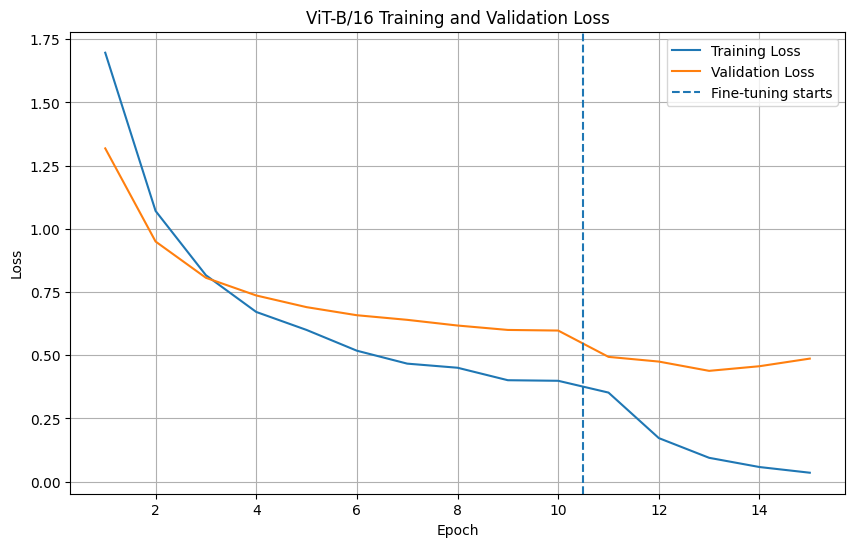

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    history["epoch"],
    history["train_loss"],
    label="Training Loss"
)

plt.plot(
    history["epoch"],
    history["val_loss"],
    label="Validation Loss"
)

plt.axvline(
    x=STAGE1_EPOCHS + 0.5,
    linestyle="--",
    label="Fine-tuning starts"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ViT-B/16 Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

##Accuracy Curve

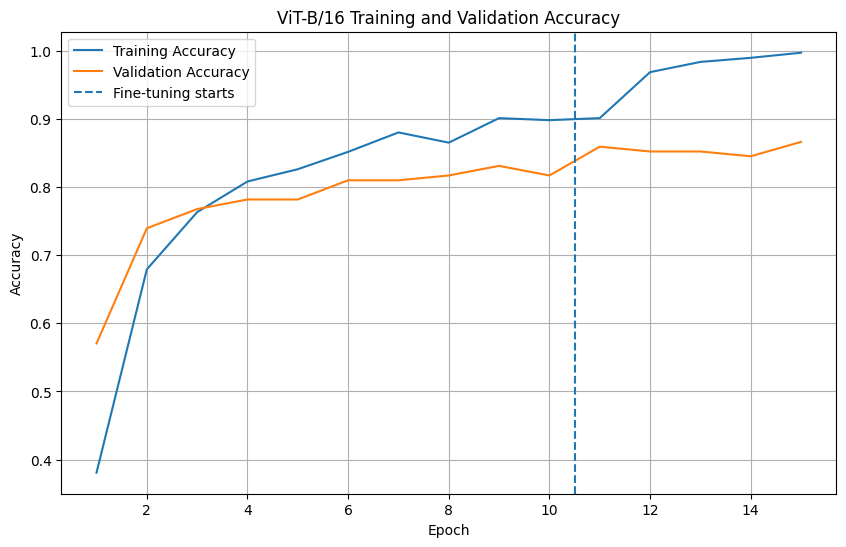

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    history["epoch"],
    history["train_accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history["epoch"],
    history["val_accuracy"],
    label="Validation Accuracy"
)

plt.axvline(
    x=STAGE1_EPOCHS + 0.5,
    linestyle="--",
    label="Fine-tuning starts"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ViT-B/16 Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

##Verify and Load Best Validation Checkpoint

In [ ]:
import os

if not os.path.exists(best_model_path):
    raise FileNotFoundError(
        f"Best checkpoint was not created: {best_model_path}"
    )

print("Best checkpoint exists.")
print("Path:", best_model_path)
print("Size:", os.path.getsize(best_model_path) / (1024 * 1024), "MB")
print("Best validation accuracy:", best_val_accuracy)
print("Best epoch:", best_epoch)

Best checkpoint exists.
Path: /content/vit_b16_best.pth
Size: 327.3780870437622 MB
Best validation accuracy: 0.8661971830985915
Best epoch: 15


In [ ]:
checkpoint = torch.load(
    best_model_path,
    map_location=device
)

model.load_state_dict(checkpoint)

model = model.to(device)

print("Best validation checkpoint loaded successfully.")
print(f"Best validation accuracy: {best_val_accuracy:.4f}")
print(f"Best epoch: {best_epoch}")

Best validation checkpoint loaded successfully.
Best validation accuracy: 0.8662
Best epoch: 15


#Final Test evaluation

In [ ]:
def get_predictions(model, loader, device):
    model.eval()

    all_predictions = []
    all_labels = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(
                device,
                non_blocking=True
            )

            outputs = model(images)

            predictions = outputs.argmax(dim=1)

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_labels.extend(
                labels.numpy()
            )

    return (
        np.array(all_labels),
        np.array(all_predictions)
    )

##Generate Test Predictions

In [ ]:
y_true, y_pred = get_predictions(
    model,
    test_loader,
    device
)

print("Number of test samples:", len(y_true))
print("Predictions generated successfully.")

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Number of test samples: 144
Predictions generated successfully.


##Test Accuracy

In [ ]:
test_accuracy = accuracy_score(
    y_true,
    y_pred
)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Accuracy: 0.8681
Test Accuracy: 86.81%


##Overall Metrics

In [ ]:
test_precision_macro = precision_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

test_recall_macro = recall_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

test_f1_macro = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

test_f1_weighted = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

print("Final Test Metrics")
print("=" * 50)

print(f"Accuracy:          {test_accuracy:.4f}")
print(f"Macro Precision:   {test_precision_macro:.4f}")
print(f"Macro Recall:      {test_recall_macro:.4f}")
print(f"Macro F1:          {test_f1_macro:.4f}")
print(f"Weighted F1:       {test_f1_weighted:.4f}")

Final Test Metrics
Accuracy:          0.8681
Macro Precision:   0.8706
Macro Recall:      0.8267
Macro F1:          0.8427
Weighted F1:       0.8700


##Per-Class Metrics

In [ ]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0
)

print(report)

                     precision    recall  f1-score   support

      gond painting       1.00      0.94      0.97        16
  kalighat painting       0.84      0.98      0.91        44
    kangra painting       0.92      0.86      0.89        14
       kerala mural       1.00      0.82      0.90        11
 madhubani painting       0.50      0.67      0.57         9
mandana art drawing       0.89      0.67      0.76        12
   pichwai painting       0.95      0.83      0.89        24
     warli painting       0.86      0.86      0.86        14

           accuracy                           0.87       144
          macro avg       0.87      0.83      0.84       144
       weighted avg       0.88      0.87      0.87       144



In [ ]:
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).transpose()

report_df

,precision,recall,f1-score,support
gond painting,1.000000,0.937500,0.967742,16.000000
kalighat painting,0.843137,0.977273,0.905263,44.000000
kangra painting,0.923077,0.857143,0.888889,14.000000
kerala mural,1.000000,0.818182,0.900000,11.000000
madhubani painting,0.500000,0.666667,0.571429,9.000000
mandana art drawing,0.888889,0.666667,0.761905,12.000000
pichwai painting,0.952381,0.833333,0.888889,24.000000
warli painting,0.857143,0.857143,0.857143,14.000000
accuracy,0.868056,0.868056,0.868056,0.868056
macro avg,0.870578,0.826738,0.842657,144.000000


##Confusion Matrix

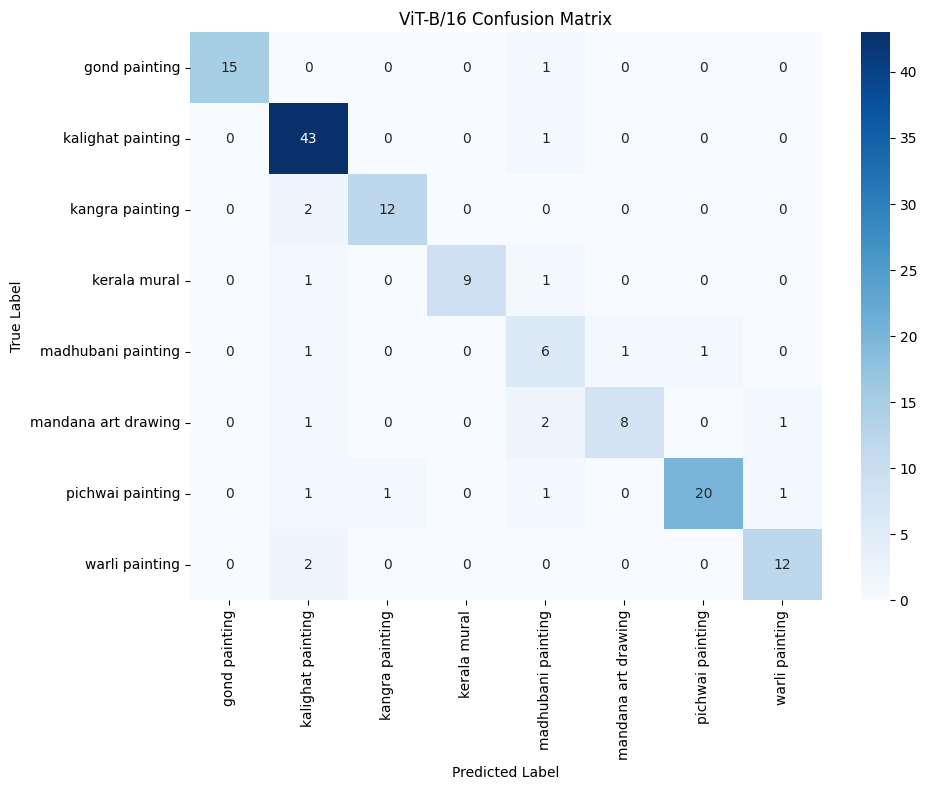

In [ ]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("ViT-B/16 Confusion Matrix")
plt.tight_layout()
plt.show()

##Final Metrics Summary

In [ ]:
final_metrics = pd.DataFrame({
    "Metric": [
        "Test Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Weighted F1",
        "Best Validation Accuracy",
        "Best Epoch"
    ],
    "Value": [
        test_accuracy,
        test_precision_macro,
        test_recall_macro,
        test_f1_macro,
        test_f1_weighted,
        best_val_accuracy,
        best_epoch
    ]
})

final_metrics

,Metric,Value
0,Test Accuracy,0.868056
1,Macro Precision,0.870578
2,Macro Recall,0.826738
3,Macro F1,0.842657
4,Weighted F1,0.869993
5,Best Validation Accuracy,0.866197
6,Best Epoch,15.000000


#Output

In [ ]:
print("=" * 70)
print("PIPELINE 3 — ViT-B/16 FINAL RESULTS")
print("=" * 70)

print(f"Architecture:             ViT-B/16")
print(f"Pretrained weights:       ImageNet-1K")
print(f"Dataset classes:          {NUM_CLASSES}")
print(f"Dataset split:            70% / 15% / 15%")
print(f"Random seed:              {SEED}")
print(f"Input size:               {IMAGE_SIZE} × {IMAGE_SIZE}")
print(f"Batch size:               {BATCH_SIZE}")
print(f"Stage 1 epochs:           {STAGE1_EPOCHS}")
print(f"Stage 2 epochs:           {STAGE2_EPOCHS}")
print(f"Fine-tuned blocks:        Final 2 encoder blocks")
print("-" * 70)
print(f"Best validation accuracy: {best_val_accuracy:.4f}")
print(f"Test accuracy:            {test_accuracy:.4f}")
print(f"Macro precision:           {test_precision_macro:.4f}")
print(f"Macro recall:              {test_recall_macro:.4f}")
print(f"Macro F1:                  {test_f1_macro:.4f}")
print(f"Weighted F1:               {test_f1_weighted:.4f}")
print("=" * 70)

PIPELINE 3 — ViT-B/16 FINAL RESULTS
Architecture:             ViT-B/16
Pretrained weights:       ImageNet-1K
Dataset classes:          8
Dataset split:            70% / 15% / 15%
Random seed:              42
Input size:               224 × 224
Batch size:               32
Stage 1 epochs:           10
Stage 2 epochs:           5
Fine-tuned blocks:        Final 2 encoder blocks
----------------------------------------------------------------------
Best validation accuracy: 0.8662
Test accuracy:            0.8681
Macro precision:           0.8706
Macro recall:              0.8267
Macro F1:                  0.8427
Weighted F1:               0.8700


In [ ]:
from google.colab import drive
import os
import shutil

# Mount Google Drive
drive.mount("/content/drive")

# --------------------------------------------------
# Set your required Google Drive folder here
# --------------------------------------------------
DRIVE_FOLDER = "/content/drive/MyDrive/Iconography/Implementation/ViT-B"

os.makedirs(DRIVE_FOLDER, exist_ok=True)

# Local best checkpoint
local_best_model = "/content/vit_b16_best.pth"

# Destination
drive_model_path = os.path.join(
    DRIVE_FOLDER,
    "ViT_B16_best_validation_checkpoint.pth"
)

# Copy to drive
shutil.copy2(
    local_best_model,
    drive_model_path
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


'/content/drive/MyDrive/Iconography/Implementation/ViT-B/ViT_B16_best_validation_checkpoint.pth'